In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

load_dotenv(override=True)

url = URL.create(
    "postgresql+psycopg2",
    username=os.environ.get("DB_USER", "postgres"),
    password=os.environ["DB_PASSWORD"],
    host=os.environ.get("DB_HOST", "localhost"),
    port=os.environ.get("DB_PORT", "5432"),
    database=os.environ.get("DB_NAME", "finguard_db"),
)
engine = create_engine(url)

# Load our engineered feature set (not the raw transactions table)
df = pd.read_sql("SELECT * FROM transactions_features", engine)
print(df.shape)

(284807, 36)


In [2]:
# Data is already in chronological order (we sorted by Time in Week 3)
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nTrain fraud rate: {train_df['Class'].mean()*100:.4f}%")
print(f"Test fraud rate: {test_df['Class'].mean()*100:.4f}%")

Train shape: (227845, 36)
Test shape: (56962, 36)

Train fraud rate: 0.1830%
Test fraud rate: 0.1317%


In [3]:
# Drop Class (target) and Amount (raw, unscaled - we use Amount_Log instead) from features
feature_cols = [c for c in df.columns if c not in ['Class', 'Amount']]

X_train = train_df[feature_cols]
y_train = train_df['Class']

X_test = test_df[feature_cols]
y_test = test_df['Class']

print(f"Features used ({len(feature_cols)}): {feature_cols}")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Features used (34): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Hour', 'Is_High_Risk_Hour', 'Amount_Log', 'Amount_Zscore', 'Is_Round_Amount', 'Txn_Count_Last_Hour']
X_train: (227845, 34), y_train: (227845,)
X_test: (56962, 34), y_test: (56962,)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data, then apply to both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

Scaling complete.
X_train_scaled shape: (227845, 34)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    precision_recall_curve, auc, roc_auc_score
)

# class_weight='balanced' handles imbalance by penalizing misclassifying the minority (fraud) class more
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression — Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# PR-AUC (the metric that actually matters here, not accuracy)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
print(f"\nPR-AUC: {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      0.95      0.98     56887
       Fraud       0.03      0.93      0.05        75

    accuracy                           0.95     56962
   macro avg       0.51      0.94      0.51     56962
weighted avg       1.00      0.95      0.97     56962

=== Confusion Matrix ===
[[54237  2650]
 [    5    70]]

PR-AUC: 0.7686
ROC-AUC: 0.9879


In [6]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)
y_pred_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]

print("=== Decision Tree — Classification Report ===")
print(classification_report(y_test, y_pred_dt, target_names=['Legit', 'Fraud']))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_dt))

precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_pred_proba_dt)
pr_auc_dt = auc(recall_dt, precision_dt)
print(f"\nPR-AUC: {pr_auc_dt:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")

=== Decision Tree — Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56887
       Fraud       0.06      0.79      0.11        75

    accuracy                           0.98     56962
   macro avg       0.53      0.88      0.55     56962
weighted avg       1.00      0.98      0.99     56962

=== Confusion Matrix ===
[[55918   969]
 [   16    59]]

PR-AUC: 0.2251
ROC-AUC: 0.8968


In [7]:
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42, sampling_strategy=0.1)  # brings fraud to 10% of majority class, not full 50/50 (avoids overcorrecting)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")

Before SMOTE: {0: 227428, 1: 417}
After SMOTE: {0: 227428, 1: 22742}


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test_scaled)
y_pred_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest — Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_rf))

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
pr_auc_rf = auc(recall_rf, precision_rf)
print(f"\nPR-AUC: {pr_auc_rf:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.60      0.79      0.68        75

    accuracy                           1.00     56962
   macro avg       0.80      0.89      0.84     56962
weighted avg       1.00      1.00      1.00     56962

=== Confusion Matrix ===
[[56847    40]
 [   16    59]]

PR-AUC: 0.7963
ROC-AUC: 0.9772


In [9]:
from xgboost import XGBClassifier

# scale_pos_weight approximates class balance without needing full SMOTE reliance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test_scaled)
y_pred_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost — Classification Report ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Fraud']))
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_xgb))

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)
print(f"\nPR-AUC: {pr_auc_xgb:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.30      0.77      0.43        75

    accuracy                           1.00     56962
   macro avg       0.65      0.89      0.72     56962
weighted avg       1.00      1.00      1.00     56962

=== Confusion Matrix ===
[[56752   135]
 [   17    58]]

PR-AUC: 0.7661
ROC-AUC: 0.9573


In [10]:
xgb_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
# Train on ORIGINAL scaled data, not SMOTE-resampled — let scale_pos_weight alone handle imbalance
xgb_v2.fit(X_train_scaled, y_train)

y_pred_xgb2 = xgb_v2.predict(X_test_scaled)
y_pred_proba_xgb2 = xgb_v2.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost (no SMOTE, scale_pos_weight only) ===")
print(classification_report(y_test, y_pred_xgb2, target_names=['Legit', 'Fraud']))
print(confusion_matrix(y_test, y_pred_xgb2))

precision_xgb2, recall_xgb2, _ = precision_recall_curve(y_test, y_pred_proba_xgb2)
pr_auc_xgb2 = auc(recall_xgb2, precision_xgb2)
print(f"\nPR-AUC: {pr_auc_xgb2:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb2):.4f}")

=== XGBoost (no SMOTE, scale_pos_weight only) ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.87      0.73      0.80        75

    accuracy                           1.00     56962
   macro avg       0.94      0.87      0.90     56962
weighted avg       1.00      1.00      1.00     56962

[[56879     8]
 [   20    55]]

PR-AUC: 0.7894
ROC-AUC: 0.9839


In [11]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train_scaled, y_train)

y_pred_lgbm = lgbm.predict(X_test_scaled)
y_pred_proba_lgbm = lgbm.predict_proba(X_test_scaled)[:, 1]

print("=== LightGBM — Classification Report ===")
print(classification_report(y_test, y_pred_lgbm, target_names=['Legit', 'Fraud']))
print(confusion_matrix(y_test, y_pred_lgbm))

precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_test, y_pred_proba_lgbm)
pr_auc_lgbm = auc(recall_lgbm, precision_lgbm)
print(f"\nPR-AUC: {pr_auc_lgbm:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lgbm):.4f}")

=== LightGBM — Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56887
       Fraud       0.04      0.77      0.08        75

    accuracy                           0.98     56962
   macro avg       0.52      0.87      0.53     56962
weighted avg       1.00      0.98      0.99     56962

[[55552  1335]
 [   17    58]]

PR-AUC: 0.4078
ROC-AUC: 0.8590


In [12]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=5,
    scoring='average_precision',
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_smote, y_train_smote)

print("Best params:", rf_search.best_params_)
print("Best CV PR-AUC:", rf_search.best_score_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 12}
Best CV PR-AUC: 0.9787576538688327


In [13]:
best_rf = rf_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test_scaled)
y_pred_proba_best_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

print("=== Tuned Random Forest — Test Set Results ===")
print(classification_report(y_test, y_pred_best_rf, target_names=['Legit', 'Fraud']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))

precision_best_rf, recall_best_rf, _ = precision_recall_curve(y_test, y_pred_proba_best_rf)
pr_auc_best_rf = auc(recall_best_rf, precision_best_rf)
print(f"\nTest PR-AUC: {pr_auc_best_rf:.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best_rf):.4f}")

=== Tuned Random Forest — Test Set Results ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.72      0.76      0.74        75

    accuracy                           1.00     56962
   macro avg       0.86      0.88      0.87     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56865    22]
 [   18    57]]

Test PR-AUC: 0.7983
Test ROC-AUC: 0.9774


In [14]:
import joblib

# Save the final model for reuse in later notebooks (SHAP, Streamlit app)
joblib.dump(best_rf, '../models/final_rf_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and scaler saved.")

Model and scaler saved.


In [15]:
import sys
!{sys.executable} -m pip install shap

In [16]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [17]:
import shap
import numpy as np

# Sample 2000 rows for SHAP analysis (representative, much faster than full 57K test set)
np.random.seed(42)
sample_idx = np.random.choice(X_test_scaled.shape[0], size=2000, replace=False)
X_test_sample = X_test_scaled[sample_idx]

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated on 2000-row sample.")
print(f"Shape: {np.array(shap_values).shape}")

SHAP values calculated on 2000-row sample.
Shape: (2000, 34, 2)


C:\Users\souja\AppData\Local\Temp\ipykernel_22064\3966916444.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_fraud, X_test_sample, feature_names=feature_cols, plot_type="bar", show=False)


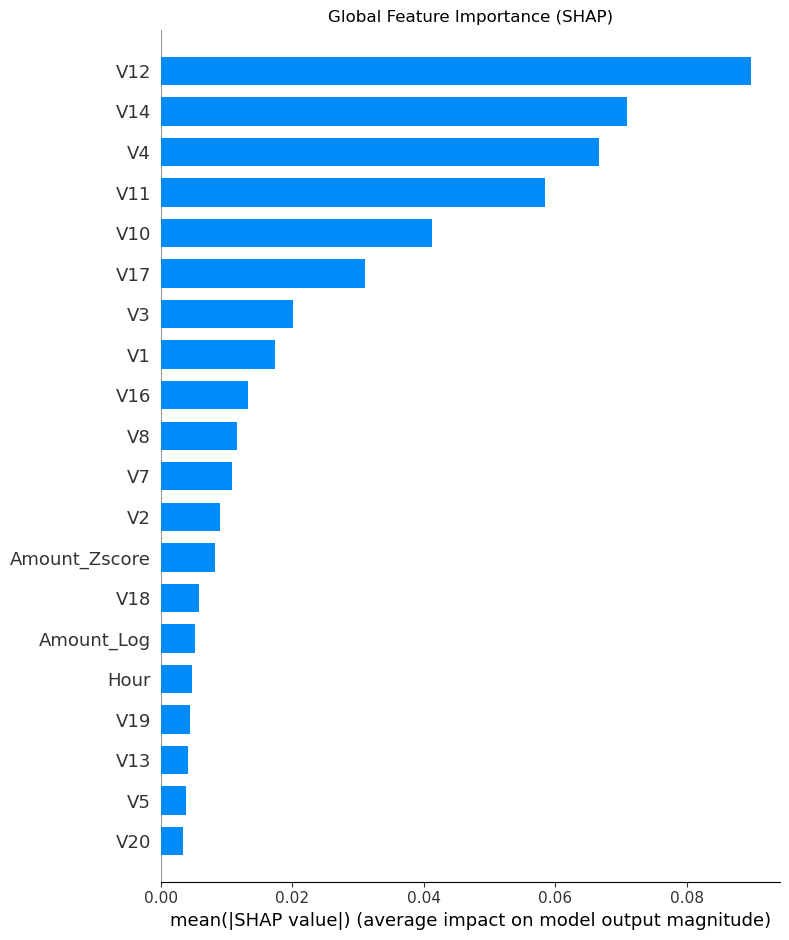

In [18]:
import matplotlib.pyplot as plt

# Use shap_values for the "Fraud" class (index 1)
shap_values_fraud = shap_values[:, :, 1] if np.array(shap_values).ndim == 3 else shap_values[1]

# Summary plot: shows feature importance ranked by impact
shap.summary_plot(shap_values_fraud, X_test_sample, feature_names=feature_cols, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("../reports/shap_feature_importance.png", dpi=150)
plt.show()

Number of fraud cases in sample: 2


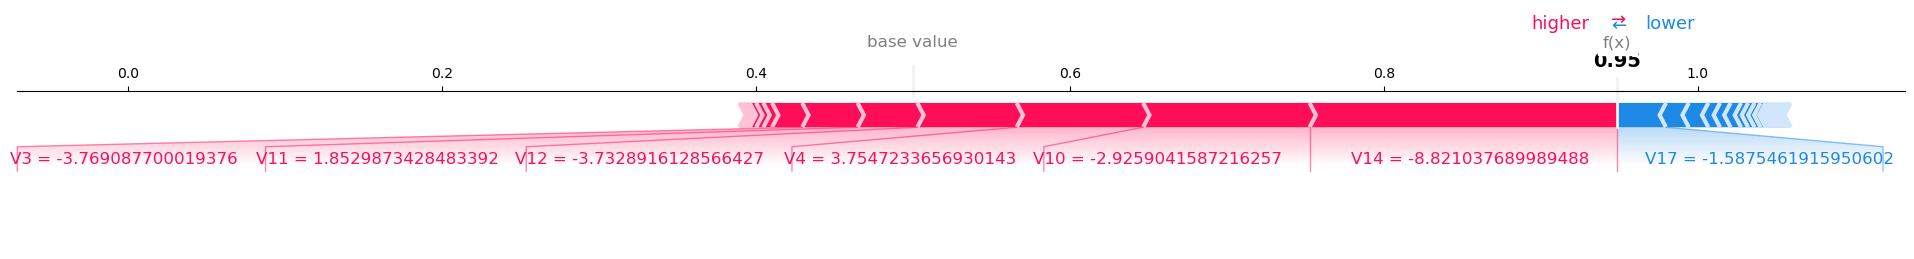

In [19]:
# Pick one actual fraud case from our sample to explain individually
fraud_indices_in_sample = np.where(y_test.iloc[sample_idx].values == 1)[0]
print(f"Number of fraud cases in sample: {len(fraud_indices_in_sample)}")

if len(fraud_indices_in_sample) > 0:
    idx_to_explain = fraud_indices_in_sample[0]
    
    shap.force_plot(
        explainer.expected_value[1], 
        shap_values_fraud[idx_to_explain], 
        X_test_sample[idx_to_explain],
        feature_names=feature_cols,
        matplotlib=True,
        show=False
    )
    plt.tight_layout()
    plt.savefig("../reports/shap_single_fraud_explanation.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No fraud cases in this sample — try a larger sample size")

In [20]:
# --- Business Impact: False-Positive Cost & Fraud Prevented ---

# Get the actual transaction amounts for the test set rows (aligned by index)
test_amounts = df.loc[y_test.index, "Amount"]

# Classify each test transaction using our final tuned model's predictions
false_negatives = (y_test == 1) & (y_pred_best_rf == 0)   # missed fraud
false_positives = (y_test == 0) & (y_pred_best_rf == 1)   # false alarm
true_positives  = (y_test == 1) & (y_pred_best_rf == 1)   # fraud caught

fraud_missed_amount = test_amounts[false_negatives].sum()
fraud_caught_amount = test_amounts[true_positives].sum()
num_false_positives = false_positives.sum()

# --- Assumption (clearly stated, not fact) ---
# Cost per false positive = manual review effort + customer friction.
# We assume ₹150 per false positive as a rough support/ops cost estimate.
COST_PER_FALSE_POSITIVE = 150

total_fp_cost = num_false_positives * COST_PER_FALSE_POSITIVE

print(f"Fraud amount successfully caught (true positives): ₹{fraud_caught_amount:,.2f}")
print(f"Fraud amount missed (false negatives):              ₹{fraud_missed_amount:,.2f}")
print(f"Number of false positives:                          {num_false_positives}")
print(f"Estimated false-positive cost (@ ₹{COST_PER_FALSE_POSITIVE}/case):  ₹{total_fp_cost:,.2f}")
print(f"Net estimated benefit (fraud caught - FP cost):     ₹{fraud_caught_amount - total_fp_cost:,.2f}")

Fraud amount successfully caught (true positives): ₹5,090.99
Fraud amount missed (false negatives):              ₹2,638.27
Number of false positives:                          22
Estimated false-positive cost (@ ₹150/case):  ₹3,300.00
Net estimated benefit (fraud caught - FP cost):     ₹1,790.99


In [21]:
# --- Export full test-set predictions for the Risk Threshold Simulator ---
test_predictions = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred_proba": y_pred_proba_best_rf,
    "Amount": df.loc[y_test.index, "Amount"].values,
})
test_predictions.to_csv("../data/test_predictions.csv", index=False)
print(f"Saved {len(test_predictions)} test predictions to data/test_predictions.csv")

Saved 56962 test predictions to data/test_predictions.csv


In [22]:
# --- Isolation Forest: Unsupervised Anomaly Detection ---
# Unlike our supervised Random Forest (which learns from KNOWN fraud examples),
# Isolation Forest learns what "normal" looks like and flags transactions that
# deviate from it — including patterns not present in our labeled fraud examples.
# This is trained WITHOUT using fraud labels at all (unsupervised).

from sklearn.ensemble import IsolationForest

# contamination = expected proportion of anomalies; we use the actual fraud rate
# in training data as a reasonable estimate
fraud_rate = y_train.mean()

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=fraud_rate,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_train_scaled)  # NOTE: no y_train — this is unsupervised

# decision_function: higher = more normal, lower = more anomalous.
# We flip the sign so higher = more anomalous, matching our fraud probability's intuition.
anomaly_scores_test = -iso_forest.decision_function(X_test_scaled)
iso_predictions_test = (iso_forest.predict(X_test_scaled) == -1).astype(int)  # -1 = anomaly, flip to 1

print("=== Isolation Forest — Test Set Results ===")
print(classification_report(y_test, iso_predictions_test, target_names=['Legit', 'Fraud']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, iso_predictions_test))

# How much does it agree with our supervised model on what's fraud?
agreement = (iso_predictions_test == y_pred_best_rf).mean()
print(f"\nAgreement with supervised Random Forest: {agreement*100:.1f}%")

=== Isolation Forest — Test Set Results ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.00      0.00      0.00        75

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56830    57]
 [   75     0]]

Agreement with supervised Random Forest: 99.8%


In [23]:
# --- Isolation Forest v2: restricted to PCA features only ---
pca_cols = [c for c in feature_cols if c.startswith("V")]
pca_col_idx = [feature_cols.index(c) for c in pca_cols]

X_train_pca_only = X_train_scaled[:, pca_col_idx]
X_test_pca_only = X_test_scaled[:, pca_col_idx]

iso_forest_v2 = IsolationForest(
    n_estimators=200,
    contamination=fraud_rate,
    random_state=42,
    n_jobs=-1,
)
iso_forest_v2.fit(X_train_pca_only)

iso_predictions_v2 = (iso_forest_v2.predict(X_test_pca_only) == -1).astype(int)

print("=== Isolation Forest v2 (PCA features only) — Test Set Results ===")
print(classification_report(y_test, iso_predictions_v2, target_names=['Legit', 'Fraud']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, iso_predictions_v2))

=== Isolation Forest v2 (PCA features only) — Test Set Results ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.02      0.01      0.02        75

    accuracy                           1.00     56962
   macro avg       0.51      0.51      0.51     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56830    57]
 [   74     1]]


In [24]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score

rf_proba_test = y_pred_proba_best_rf
iso_scores_test = -iso_forest_v2.decision_function(X_test_pca_only)
iso_scores_norm = MinMaxScaler().fit_transform(iso_scores_test.reshape(-1, 1)).flatten()

for rf_weight in [1.0, 0.9, 0.7, 0.5]:
    iso_weight = 1 - rf_weight
    combined_score = (rf_weight * rf_proba_test) + (iso_weight * iso_scores_norm)
    combined_pred = (combined_score >= 0.40).astype(int)

    prec = precision_score(y_test, combined_pred)
    rec = recall_score(y_test, combined_pred)
    print(f"RF weight={rf_weight}, ISO weight={iso_weight:.1f} → Precision: {prec:.3f}, Recall: {rec:.3f}")

RF weight=1.0, ISO weight=0.0 → Precision: 0.448, Recall: 0.800
RF weight=0.9, ISO weight=0.1 → Precision: 0.526, Recall: 0.800
RF weight=0.7, ISO weight=0.3 → Precision: 0.628, Recall: 0.787
RF weight=0.5, ISO weight=0.5 → Precision: 0.431, Recall: 0.787


In [25]:
# --- Save Isolation Forest + properly-fit score scaler for use in the app ---
import joblib

# Fit the anomaly-score scaler on TRAINING data only (not test) — avoids leakage
iso_scores_train = -iso_forest_v2.decision_function(X_train_pca_only)
iso_score_scaler = MinMaxScaler()
iso_score_scaler.fit(iso_scores_train.reshape(-1, 1))

# Re-verify precision/recall with the properly-fit scaler (should be very close to before)
iso_scores_test_v2 = -iso_forest_v2.decision_function(X_test_pca_only)
iso_scores_norm_v2 = iso_score_scaler.transform(iso_scores_test_v2.reshape(-1, 1)).flatten()

combined_score_final = (0.7 * rf_proba_test) + (0.3 * iso_scores_norm_v2)
combined_pred_final = (combined_score_final >= 0.40).astype(int)

print("=== Final Combined Model (RF 0.7 / Isolation Forest 0.3) — properly fit scaler ===")
print(f"Precision: {precision_score(y_test, combined_pred_final):.3f}")
print(f"Recall: {recall_score(y_test, combined_pred_final):.3f}")

# Save everything the app will need
joblib.dump(iso_forest_v2, "../models/isolation_forest.pkl")
joblib.dump(iso_score_scaler, "../models/iso_score_scaler.pkl")
joblib.dump(pca_col_idx, "../models/pca_col_idx.pkl")  # which feature indices are the V1-V28 columns
print("\nSaved: isolation_forest.pkl, iso_score_scaler.pkl, pca_col_idx.pkl")

=== Final Combined Model (RF 0.7 / Isolation Forest 0.3) — properly fit scaler ===
Precision: 0.628
Recall: 0.787

Saved: isolation_forest.pkl, iso_score_scaler.pkl, pca_col_idx.pkl


In [26]:
# --- Create audit_log table for storing every risk assessment made ---
from sqlalchemy import text

with engine.connect() as conn:
    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS audit_log (
            id SERIAL PRIMARY KEY,
            timestamp TIMESTAMP DEFAULT NOW(),
            transaction_label TEXT,
            amount NUMERIC,
            rf_score NUMERIC,
            anomaly_score NUMERIC,
            combined_score NUMERIC,
            recommended_action TEXT,
            actual_label TEXT
        )
    """))
    conn.commit()

print("audit_log table created (or already existed)")

audit_log table created (or already existed)


In [27]:
# --- Add investigator decision tracking to audit_log ---
with engine.connect() as conn:
    conn.execute(text("""
        ALTER TABLE audit_log
        ADD COLUMN IF NOT EXISTS investigator_decision TEXT,
        ADD COLUMN IF NOT EXISTS decided_at TIMESTAMP
    """))
    conn.commit()
print("audit_log extended with investigator_decision, decided_at")

audit_log extended with investigator_decision, decided_at


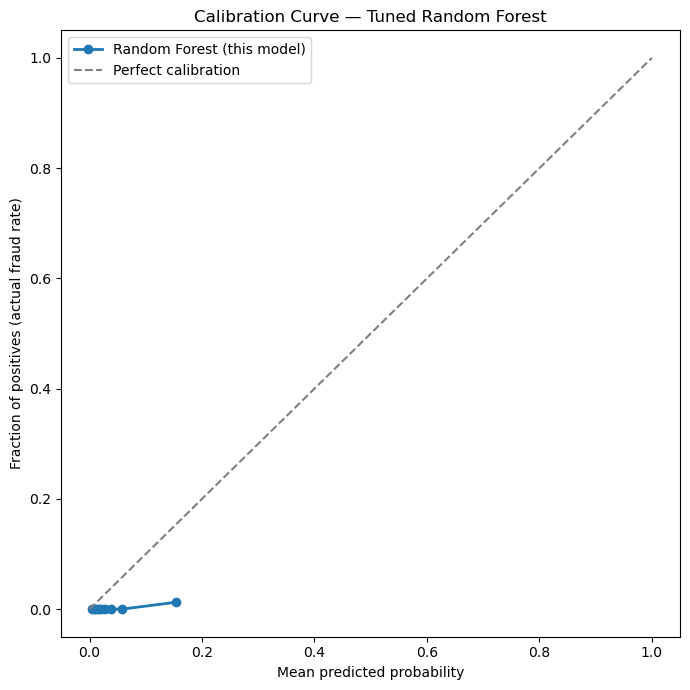

Brier score: 0.0035 (0 = perfectly calibrated, 0.25 = no better than always predicting 0.5)

Bin-by-bin comparison:
  Predicted ~0.4% → Actual 0.0% (gap: 0.4pp)
  Predicted ~0.7% → Actual 0.0% (gap: 0.7pp)
  Predicted ~1.0% → Actual 0.0% (gap: 1.0pp)
  Predicted ~1.3% → Actual 0.0% (gap: 1.3pp)
  Predicted ~1.6% → Actual 0.0% (gap: 1.6pp)
  Predicted ~2.1% → Actual 0.0% (gap: 2.1pp)
  Predicted ~2.7% → Actual 0.0% (gap: 2.7pp)
  Predicted ~3.8% → Actual 0.0% (gap: 3.8pp)
  Predicted ~5.9% → Actual 0.0% (gap: 5.8pp)
  Predicted ~15.3% → Actual 1.2% (gap: 14.1pp)


In [28]:
# --- Model Calibration Check ---
# Question: when the model says "70% fraud risk", is it actually right ~70% of the time?
# A model can have strong precision/recall but still be poorly CALIBRATED --
# meaning its probability outputs don't reflect true likelihood. This matters
# a lot for a risk system, since we use probability THRESHOLDS (40%, 80%) to
# make decisions -- if the scores are miscalibrated, those thresholds don't
# mean what we think they mean.

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Get the RF's predicted probabilities on the test set (already computed earlier as y_pred_proba_best_rf)
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_best_rf, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(prob_pred, prob_true, marker='o', label='Random Forest (this model)', linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives (actual fraud rate)')
ax.set_title('Calibration Curve — Tuned Random Forest')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/calibration_curve.png', dpi=120)
plt.show()

# Quantify the gap: Brier score (lower = better calibrated, 0 = perfect)
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, y_pred_proba_best_rf)
print(f"Brier score: {brier:.4f} (0 = perfectly calibrated, 0.25 = no better than always predicting 0.5)")

print("\nBin-by-bin comparison:")
for pt, pp in zip(prob_true, prob_pred):
    gap = abs(pt - pp)
    flag = " ⚠️ notable gap" if gap > 0.15 else ""
    print(f"  Predicted ~{pp*100:.1f}% → Actual {pt*100:.1f}% (gap: {gap*100:.1f}pp){flag}")

In [29]:
prob_true_uniform, prob_pred_uniform = calibration_curve(y_test, y_pred_proba_best_rf, n_bins=10, strategy='uniform')

print("Uniform bins (equal width 0-100%, shows the full range):")
for pt, pp in zip(prob_true_uniform, prob_pred_uniform):
    gap = abs(pt - pp)
    flag = " ⚠️ notable gap" if gap > 0.15 else ""
    print(f"  Predicted ~{pp*100:.1f}% → Actual {pt*100:.1f}% (gap: {gap*100:.1f}pp){flag}")

Uniform bins (equal width 0-100%, shows the full range):
  Predicted ~2.4% → Actual 0.0% (gap: 2.4pp)
  Predicted ~13.8% → Actual 0.1% (gap: 13.7pp)
  Predicted ~24.2% → Actual 0.3% (gap: 23.9pp) ⚠️ notable gap
  Predicted ~34.0% → Actual 1.9% (gap: 32.0pp) ⚠️ notable gap
  Predicted ~44.0% → Actual 5.5% (gap: 38.6pp) ⚠️ notable gap
  Predicted ~53.5% → Actual 11.8% (gap: 41.7pp) ⚠️ notable gap
  Predicted ~65.6% → Actual 25.0% (gap: 40.6pp) ⚠️ notable gap
  Predicted ~75.0% → Actual 100.0% (gap: 25.0pp) ⚠️ notable gap
  Predicted ~86.4% → Actual 100.0% (gap: 13.6pp)
  Predicted ~98.2% → Actual 97.6% (gap: 0.6pp)


In [30]:
# --- Fix: Recalibrate probabilities using CalibratedClassifierCV ---
# Our earlier calibration check showed the model is significantly overconfident
# in the 30-65% predicted range (a known side-effect of training on SMOTE-balanced
# data, then evaluating on the true imbalanced distribution). CalibratedClassifierCV
# fixes this by learning a correction mapping from raw scores -> true probabilities,
# fit on held-out folds so it doesn't just memorize the training data.

from sklearn.calibration import CalibratedClassifierCV

# 'sigmoid' = Platt scaling, works well with limited data; 'isotonic' is more
# flexible but needs more data to avoid overfitting -- sigmoid is the safer choice
# given our fraud class has few examples.
calibrated_rf = CalibratedClassifierCV(best_rf, method='sigmoid', cv=3)
calibrated_rf.fit(X_train_smote, y_train_smote)

y_pred_proba_calibrated = calibrated_rf.predict_proba(X_test_scaled)[:, 1]

# Re-check calibration with the fixed model
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_pred_proba_calibrated, n_bins=10, strategy='uniform')

print("=== Calibration AFTER fix ===")
for pt, pp in zip(prob_true_cal, prob_pred_cal):
    gap = abs(pt - pp)
    flag = " ⚠️ notable gap" if gap > 0.15 else " ✅"
    print(f"  Predicted ~{pp*100:.1f}% → Actual {pt*100:.1f}% (gap: {gap*100:.1f}pp){flag}")

brier_calibrated = brier_score_loss(y_test, y_pred_proba_calibrated)
print(f"\nBrier score after calibration: {brier_calibrated:.4f} (before: {brier:.4f})")

# Confirm precision/recall didn't degrade from this fix
y_pred_calibrated_binary = (y_pred_proba_calibrated >= 0.40).astype(int)
print(f"\nPrecision @ 40% threshold (calibrated): {precision_score(y_test, y_pred_calibrated_binary):.3f}")
print(f"Recall @ 40% threshold (calibrated): {recall_score(y_test, y_pred_calibrated_binary):.3f}")

# Save the calibrated model to replace the uncalibrated one
import joblib
joblib.dump(calibrated_rf, "../models/final_rf_model_calibrated.pkl")
print("\nSaved calibrated model to models/final_rf_model_calibrated.pkl")

=== Calibration AFTER fix ===
  Predicted ~0.3% → Actual 0.0% (gap: 0.2pp) ✅
  Predicted ~13.9% → Actual 1.4% (gap: 12.5pp) ✅
  Predicted ~24.7% → Actual 5.4% (gap: 19.2pp) ⚠️ notable gap
  Predicted ~33.0% → Actual 15.0% (gap: 18.0pp) ⚠️ notable gap
  Predicted ~47.8% → Actual 0.0% (gap: 47.8pp) ⚠️ notable gap
  Predicted ~57.3% → Actual 100.0% (gap: 42.7pp) ⚠️ notable gap
  Predicted ~64.1% → Actual 100.0% (gap: 35.9pp) ⚠️ notable gap
  Predicted ~75.0% → Actual 100.0% (gap: 25.0pp) ⚠️ notable gap
  Predicted ~85.9% → Actual 88.9% (gap: 2.9pp) ✅
  Predicted ~94.1% → Actual 100.0% (gap: 5.9pp) ✅

Brier score after calibration: 0.0005 (before: 0.0035)

Precision @ 40% threshold (calibrated): 0.932
Recall @ 40% threshold (calibrated): 0.733

Saved calibrated model to models/final_rf_model_calibrated.pkl
